# JEPA evaluation — spatial tumor treatment

This notebook explores the four-channel tumor dataset and evaluates a trained decoder-free JEPA model.

The questions are:

1. **Does the dataset contain a learnable treatment signal?** Chemotherapy should reduce tumor growth while also harming healthy tissue.
2. **Did JEPA learn useful dynamics?** Multi-step latent rollouts must beat persistence.
3. **Does the latent retain both objectives?** `tumor_count` and `healthy_count` must be linearly readable.
4. **Does the model understand dose response?** It must predict both tumor reduction and healthy-cell toxicity.
5. **Can multi-objective MPC trade tumor burden against tissue preservation and dose?**

The ABM is phenomenological and intended as a control benchmark, not a calibrated biological model.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Make this work whether Jupyter starts in the repository root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from koopman_control.paths import output_root

OUTPUT_ROOT = output_root()
RUN_DIR = Path(OUTPUT_ROOT / "jepa_training/jepa-tumor-v2-h10-linear-ema999")
if not RUN_DIR.is_absolute():
    RUN_DIR = PROJECT_ROOT / RUN_DIR

run_config_path = RUN_DIR / "config.json"
if run_config_path.exists():
    RUN_CONFIG = json.loads(run_config_path.read_text())
    DATASET = Path(RUN_CONFIG["dataset"])
    if not DATASET.is_absolute():
        DATASET = PROJECT_ROOT / DATASET
else:
    RUN_CONFIG = {}
    DATASET = PROJECT_ROOT / "data/tumor_tissue_images_v2/dataset.h5"

MANIFEST = DATASET.parent / "manifest.json"
CHECKPOINTS = sorted((RUN_DIR / "checkpoints").glob("best-*.ckpt"))
CKPT = max(CHECKPOINTS, key=lambda p: p.stat().st_mtime) if CHECKPOINTS else None
METRICS = RUN_DIR / "logs/metrics.csv"
MODEL_READY = CKPT is not None and METRICS.exists()
print(f"dataset:     {DATASET}")
print(f"run:         {RUN_DIR}")
print(f"checkpoint:  {CKPT}")
print(f"model ready: {MODEL_READY}")
if not MODEL_READY:
    print("Dataset exploration works now; model-evaluation cells require a completed training run.")

dataset:     /Users/jacobevarts/BagheriLab/abm-control/data/tumor_tissue_images_v2/dataset.h5
run:         /Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-tumor-v2-h10-linear-ema999
checkpoint:  /Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-tumor-v2-h10-linear-ema999/checkpoints/best-001-4512-0.013358.ckpt
model ready: True


## 1. Dataset inventory

Frames have shape `(time, 4, height, width)`: healthy occupancy, tumor occupancy, nutrient concentration, and drug concentration. The HDF5 file stores all four as `uint8`; dividing by `frame_scale=255` recovers values in `[0, 1]`.

The observables are compact macrostates used only for evaluation and the post-hoc MPC readout—not as JEPA training targets.

In [2]:
manifest = json.loads(MANIFEST.read_text()) if MANIFEST.exists() else {}
with h5py.File(DATASET, "r") as h5:
    run_ids = sorted(h5["runs"])
    obs_names = [x.decode() if isinstance(x, bytes) else str(x) for x in h5.attrs["obs_names"]]
    frame_scale = float(h5.attrs.get("frame_scale", 1.0))
    splits = {s: sum(h5["runs"][r].attrs["split"] == s for r in run_ids) for s in ("train", "val", "test")}
    excitations = {}
    shapes = set()
    for r in run_ids:
        g = h5["runs"][r]
        exc = str(g.attrs["excitation"])
        excitations[exc] = excitations.get(exc, 0) + 1
        shapes.add(g["frames"].shape)

print(f"runs: {len(run_ids)}  split counts: {splits}")
print(f"frame shapes: {sorted(shapes)}  frame_scale: {frame_scale:g}")
print(f"observables ({len(obs_names)}): {obs_names}")
print("excitation counts:", dict(sorted(excitations.items())))
print("ABM config:", manifest.get("config", {}))

runs: 630  split counts: {'train': 378, 'val': 126, 'test': 126}
frame shapes: [(201, 4, 64, 64)]  frame_scale: 255
observables (12): ['tumor_count', 'healthy_count', 'tumor_frac', 'healthy_frac', 'healthy_loss', 'tumor_centroid_x', 'tumor_centroid_y', 'tumor_spread', 'mean_nutrient', 'mean_drug', 'tumor_drug_exposure', 'healthy_drug_exposure']
excitation counts: {'chirp': 90, 'constant': 90, 'prbs': 90, 'ramp': 90, 'rpwc': 90, 'staircase': 90, 'zero': 90}
ABM config: {'steps': 200, 'seeds': 5, 'seed_offset': 700, 'initial_healthy_frac': [0.9, 0.94], 'initial_tumor_radius': [4.0, 6.0, 8.0], 'tumor_centers': [[0.3, 0.3], [0.5, 0.5], [0.7, 0.7]], 'excitations': ['zero', 'constant', 'rpwc', 'prbs', 'ramp', 'staircase', 'chirp'], 'width': 64, 'height': 64, 'vessel_spacing': 16, 'nutrient_source': 1.0, 'nutrient_diffusion': 0.18, 'nutrient_recovery': 0.08, 'healthy_consumption': 0.002, 'tumor_consumption': 0.004, 'drug_diffusion': 0.25, 'drug_delivery': 0.2, 'drug_decay': 0.08, 'healthy_gro

## 2. Spatial channels through time

This is the key difference from the spatially homogeneous wolf–rabbit case: treatment diffuses from the boundary, nutrient and drug form fields, and the localized tumor front interacts with nearby healthy tissue.

Choose any trajectory below. Binary channels use occupancy; continuous channels use the decoded concentration.

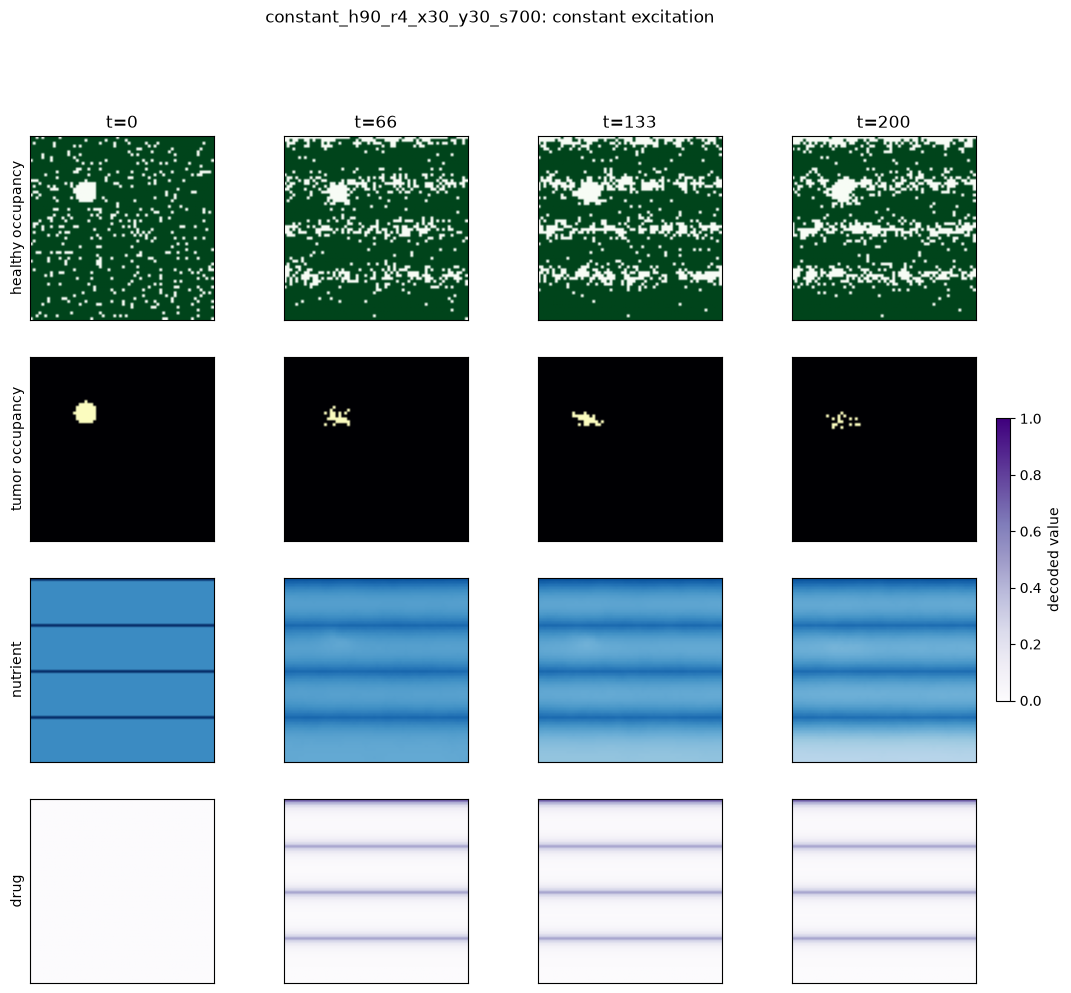

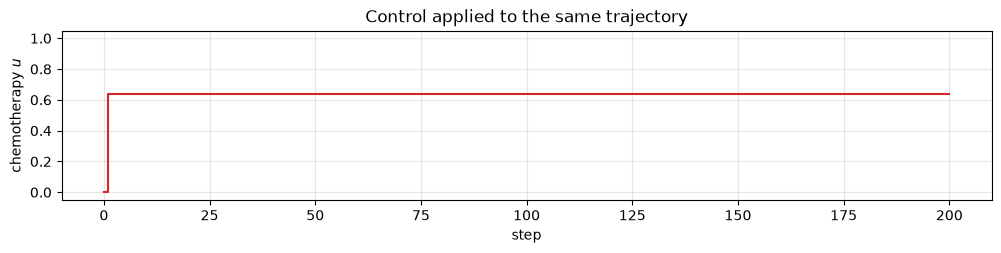

In [3]:
EXAMPLE_EXCITATION = "constant"
with h5py.File(DATASET, "r") as h5:
    candidates = [r for r in sorted(h5["runs"]) if str(h5["runs"][r].attrs["excitation"]) == EXAMPLE_EXCITATION]
    example_id = candidates[0] if candidates else sorted(h5["runs"])[0]
    g = h5["runs"][example_id]
    frames = np.asarray(g["frames"], dtype=np.float32) / float(h5.attrs.get("frame_scale", 1.0))
    controls = np.asarray(g["control"], dtype=float)
    example_meta = dict(g.attrs)

channel_names = ["healthy occupancy", "tumor occupancy", "nutrient", "drug"]
cmaps = ["Greens", "magma", "Blues", "Purples"]
times = np.linspace(0, len(frames) - 1, 4, dtype=int)
fig, axes = plt.subplots(4, len(times), figsize=(13, 11), squeeze=False)
for row, (name, cmap) in enumerate(zip(channel_names, cmaps)):
    for col, t in enumerate(times):
        im = axes[row, col].imshow(frames[t, row], vmin=0, vmax=1, cmap=cmap)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        if row == 0:
            axes[row, col].set_title(f"t={t}")
        if col == 0:
            axes[row, col].set_ylabel(name)
fig.colorbar(im, ax=axes, fraction=0.014, pad=0.02, label="decoded value")
fig.suptitle(f"{example_id}: {example_meta['excitation']} excitation", y=0.995)
plt.show()

plt.figure(figsize=(12, 2.2))
plt.step(np.arange(len(controls)), controls, where="post", color="C3")
plt.ylim(-0.05, 1.05); plt.xlabel("step"); plt.ylabel("chemotherapy $u$")
plt.title("Control applied to the same trajectory"); plt.grid(alpha=0.3); plt.show()

## 3. Do the excitation regimes create useful system-identification data?

A useful dataset must contain both untreated growth and varied treatment timing/intensity. The plots below compare one trajectory from each excitation family. Look for a graded tumor response and a conflicting healthy-cell response—not just immediate extinction under every nonzero dose.

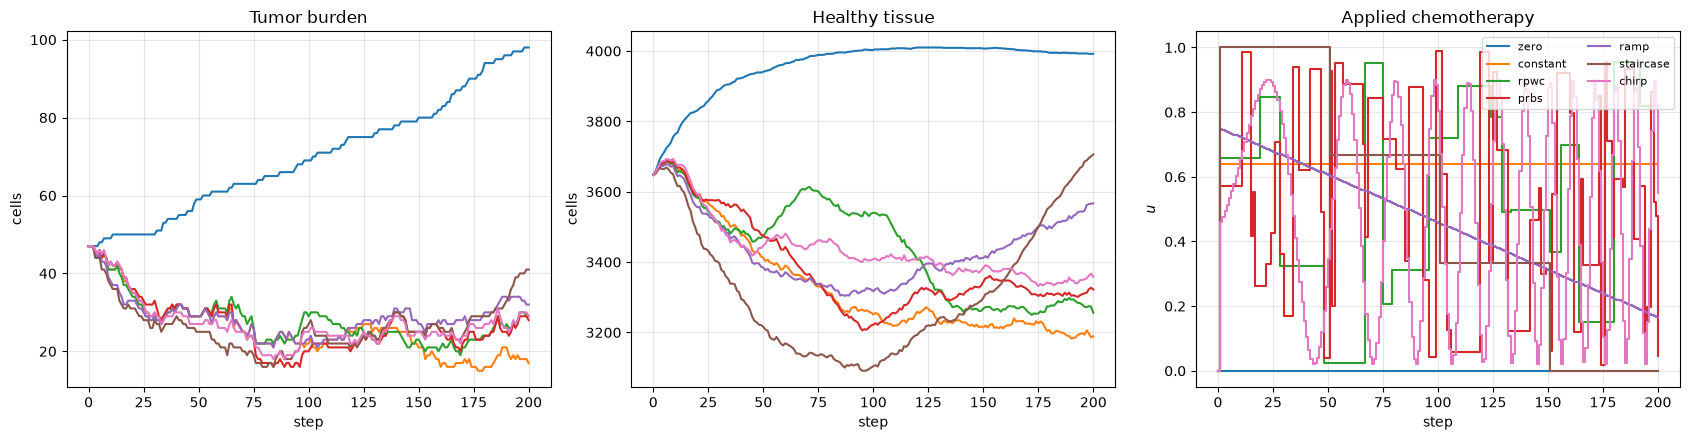

In [4]:
preferred = ["zero", "constant", "rpwc", "prbs", "ramp", "staircase", "chirp"]
trajectories = {}
with h5py.File(DATASET, "r") as h5:
    names = [x.decode() if isinstance(x, bytes) else str(x) for x in h5.attrs["obs_names"]]
    ti, hi = names.index("tumor_count"), names.index("healthy_count")
    for run_id in sorted(h5["runs"]):
        g = h5["runs"][run_id]
        exc = g.attrs["excitation"]
        exc = exc.decode() if isinstance(exc, bytes) else str(exc)
        if exc in preferred and exc not in trajectories:
            trajectories[exc] = {
                "obs": np.asarray(g["obs"], dtype=float),
                "u": np.asarray(g["control"], dtype=float),
            }

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for exc in preferred:
    if exc not in trajectories:
        continue
    tr = trajectories[exc]
    axes[0].plot(tr["obs"][:, ti], label=exc)
    axes[1].plot(tr["obs"][:, hi], label=exc)
    axes[2].step(np.arange(len(tr["u"])), tr["u"], where="post", label=exc)
axes[0].set_title("Tumor burden"); axes[0].set_ylabel("cells")
axes[1].set_title("Healthy tissue"); axes[1].set_ylabel("cells")
axes[2].set_title("Applied chemotherapy"); axes[2].set_ylabel("$u$")
for ax in axes:
    ax.set_xlabel("step"); ax.grid(alpha=0.3)
axes[2].legend(fontsize=8, ncol=2)
fig.tight_layout(); plt.show()

## 4. Load the trained JEPA and compute shared diagnostics

Set `RUN_DIR` in the setup cell if your run name differs. This cell deliberately fails with a clear message when training has not produced a checkpoint yet.

The readout is fit only on training trajectories. Validation trajectories remain held out for all figures below. Tumor centroids are excluded because they are undefined or unstable when the tumor becomes very small.

In [5]:
if not MODEL_READY:
    raise FileNotFoundError(
        f"No completed run at {RUN_DIR}. Update RUN_DIR or finish training before running this cell."
    )

from jepa_control import evaluate as ev
from jepa_control import plots as jp

N_PROBE_TRAIN = 40
SCORE_HORIZON = int(RUN_CONFIG.get("horizon", 20))
CONTROL_OBS = "tumor_count"

model = ev.load_model(CKPT)
val = ev.load_split_trajectories(DATASET, "val")
test = ev.load_split_trajectories(DATASET, "test")
probe_train = ev.load_split_trajectories(DATASET, "train", N_PROBE_TRAIN)

# Encode once and reuse the expensive convolutional outputs.
enc = ev.encode_all(model, val)
enc_train = ev.encode_all(model, probe_train)
readout = ev.fit_readout(enc_train)
r2_val = ev.readout_r2(readout, enc)

fitted = ev.fit_latent_linear(model, enc)
herr = ev.horizon_errors(model, enc, fitted)
pca = ev.latent_pca(enc)
probe = ev.linear_probe(model, probe_train, val)
tumor_skill = ev.readout_rollout_skill(model, enc, readout, obs_name="tumor_count")
healthy_skill = ev.readout_rollout_skill(model, enc, readout, obs_name="healthy_count")

h = min(SCORE_HORIZON, len(herr["steps"]) - 1)
print(f"latent dim: {model.latent_dim}; training horizon: {model.hparams.horizon}")
print(f"held-out trajectories: {len(val)} validation / {len(test)} test")
print(f"effective latent dimensions: {pca['participation_ratio']:.1f}; 95% variance in {pca['n95']} PCs")
print(f"prediction skill at h={h}: {herr['skill_full'][h]:+.3f} (persistence {herr['skill_persistence'][h]:+.3f})")
print(f"tumor readout R²: {r2_val['tumor_count']:+.3f}; rollout corr: {tumor_skill['corr']:+.3f}")
print(f"healthy readout R²: {r2_val['healthy_count']:+.3f}; rollout corr: {healthy_skill['corr']:+.3f}")

latent dim: 16; training horizon: 10
held-out trajectories: 126 validation / 126 test
effective latent dimensions: 4.4; 95% variance in 5 PCs
prediction skill at h=10: +0.885 (persistence +0.974)
tumor readout R²: +0.854; rollout corr: +0.018
healthy readout R²: +0.545; rollout corr: +0.106


## 5. Training health and multi-step dynamics

The first figure checks optimization and collapse. The participation ratio should not steadily decay toward one.

The second figure is the most important dynamics test. Positive skill means the rollout beats predicting the mean latent; the JEPA curve should also beat **persistence**, which simply freezes the initial latent. Judge the model most strongly near its training horizon; much longer rollouts are extrapolation.

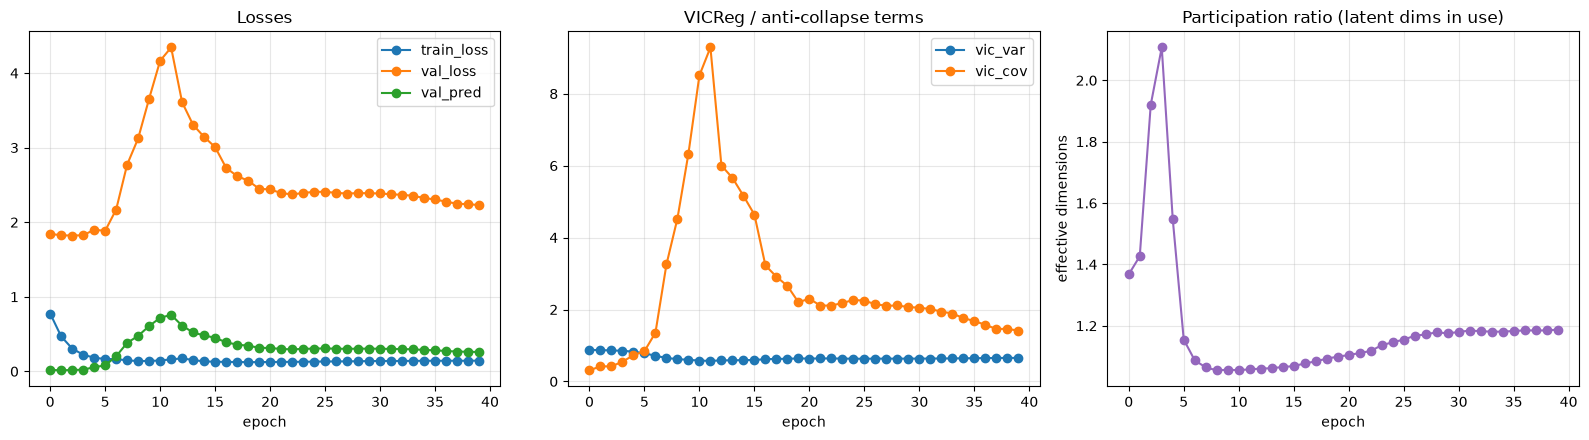

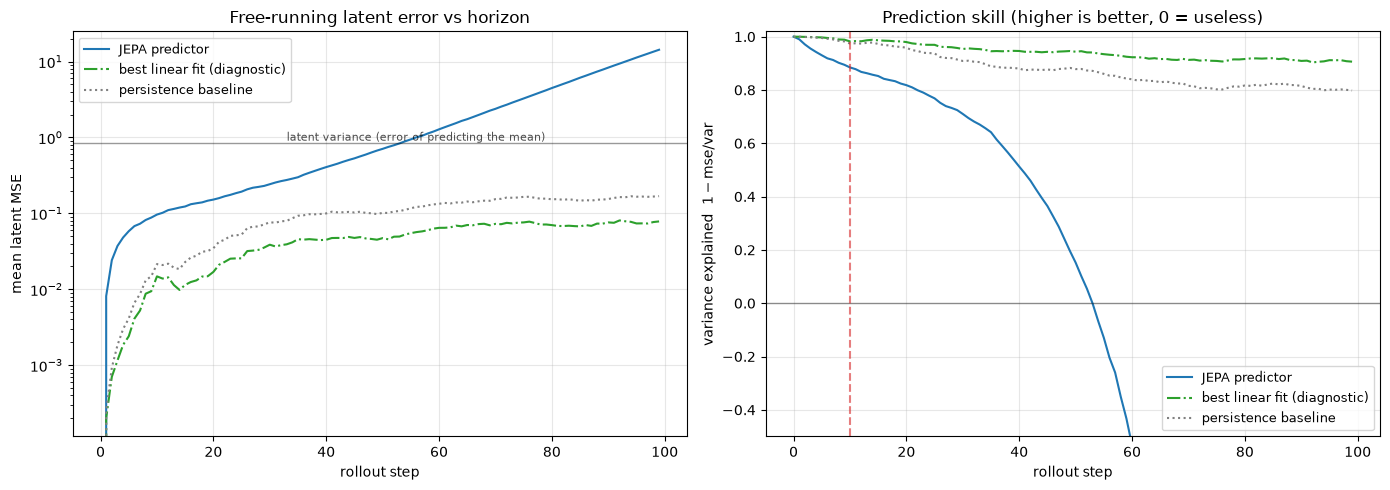

In [6]:
jp.fig_learning_curves(METRICS)
plt.show()

jp.fig_horizon_errors(herr, max_step=min(100, len(herr["steps"])))
plt.axvline(SCORE_HORIZON, color="C3", ls="--", alpha=0.6, label="training horizon")
plt.show()

## 6. Is the latent structured around the quantities needed for control?

PCA is a qualitative check: smooth tumor/healthy gradients indicate that biologically relevant state occupies dominant latent directions. The ridge probe is stricter: MPC requires tumor burden and healthy tissue to be recoverable from the latent, while `u_applied` measures whether current drug exposure leaves a detectable signature.

High readout quality alone is not enough—the model must also carry those quantities accurately through a free rollout.

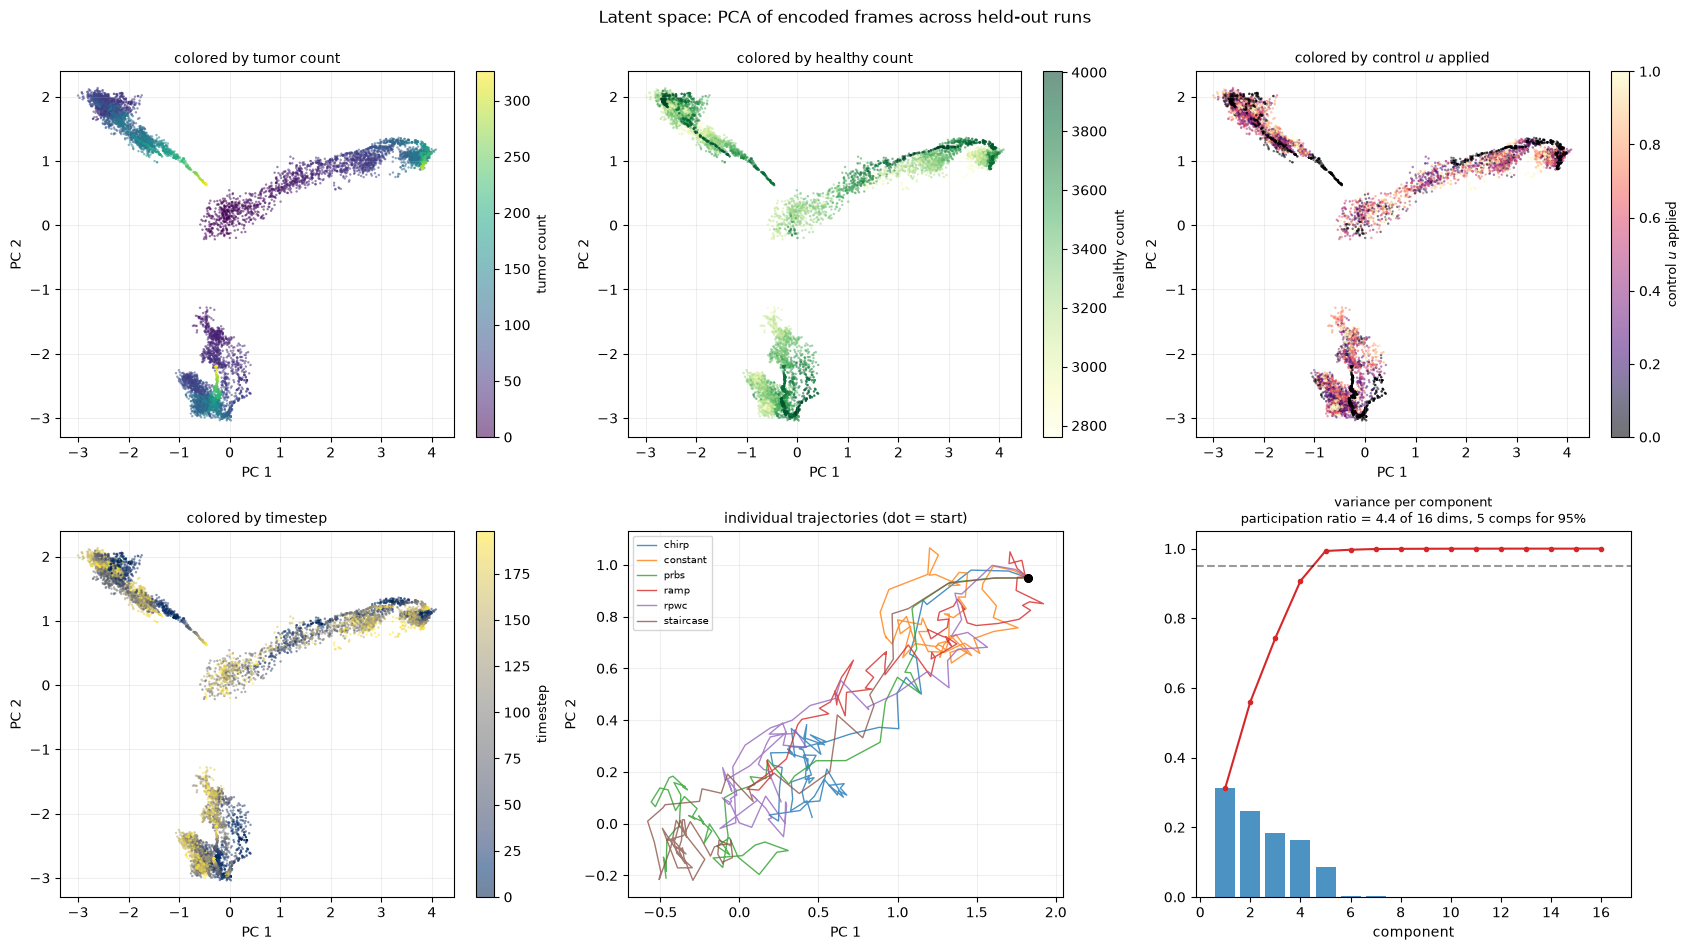

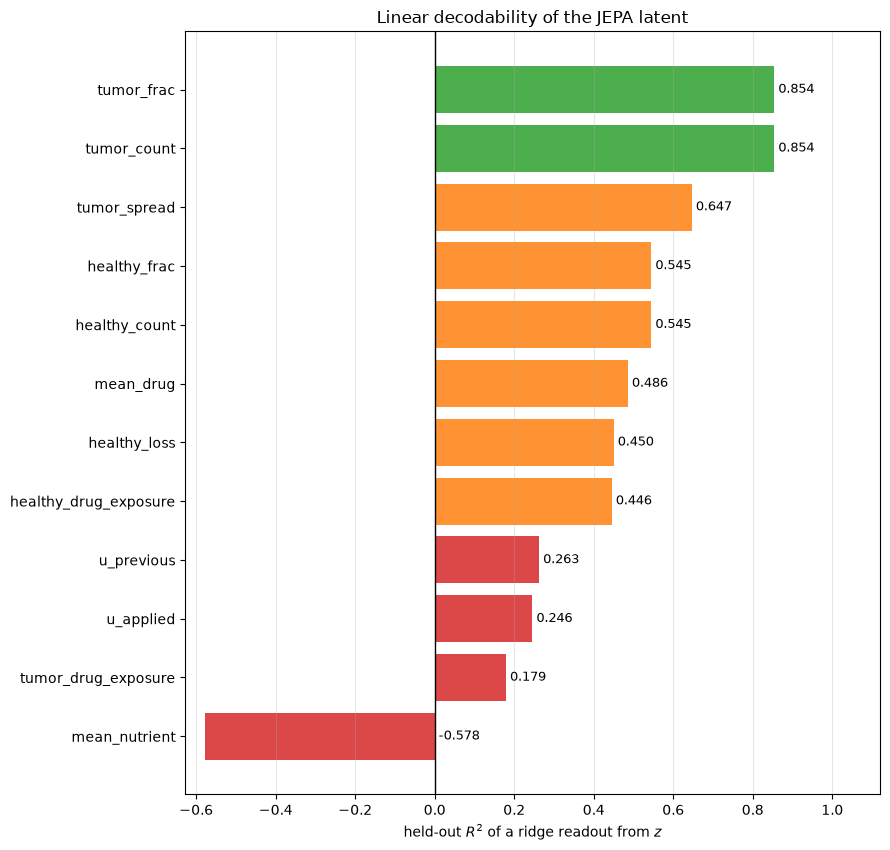

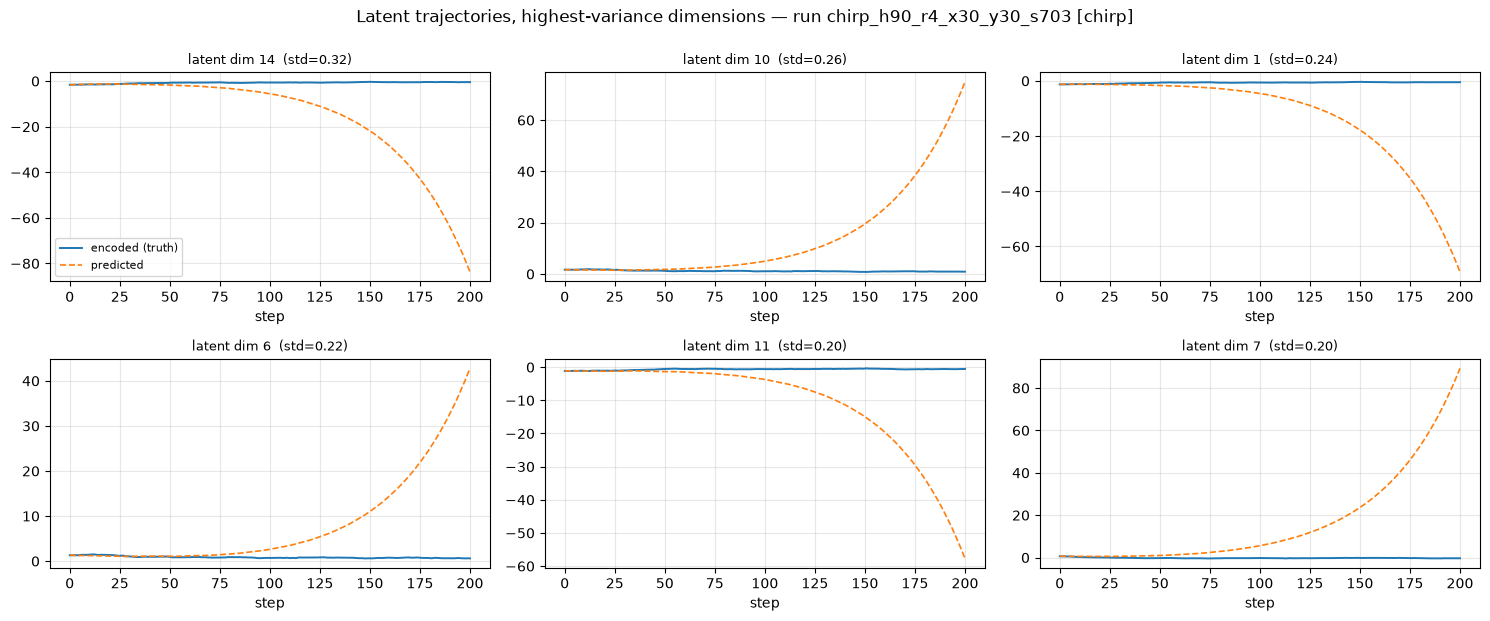

In [7]:
jp.fig_latent_pca(pca, stride=3, n_traj_lines=6)
plt.show()

jp.fig_latent_probe(probe)
plt.show()

jp.fig_latent_traces(model, val[0], n_dims=6)
plt.show()

## 7. Decoder-free readout and free-running macrostates

JEPA never reconstructs pixels. A post-hoc linear map converts predicted latents into the few observables needed by the controller. The scatter panels test static recoverability; the rollout panels test whether errors accumulate in the quantities that define the control objective.

The control shading is the chemotherapy supplied to the predictor—not an input inferred from the image.

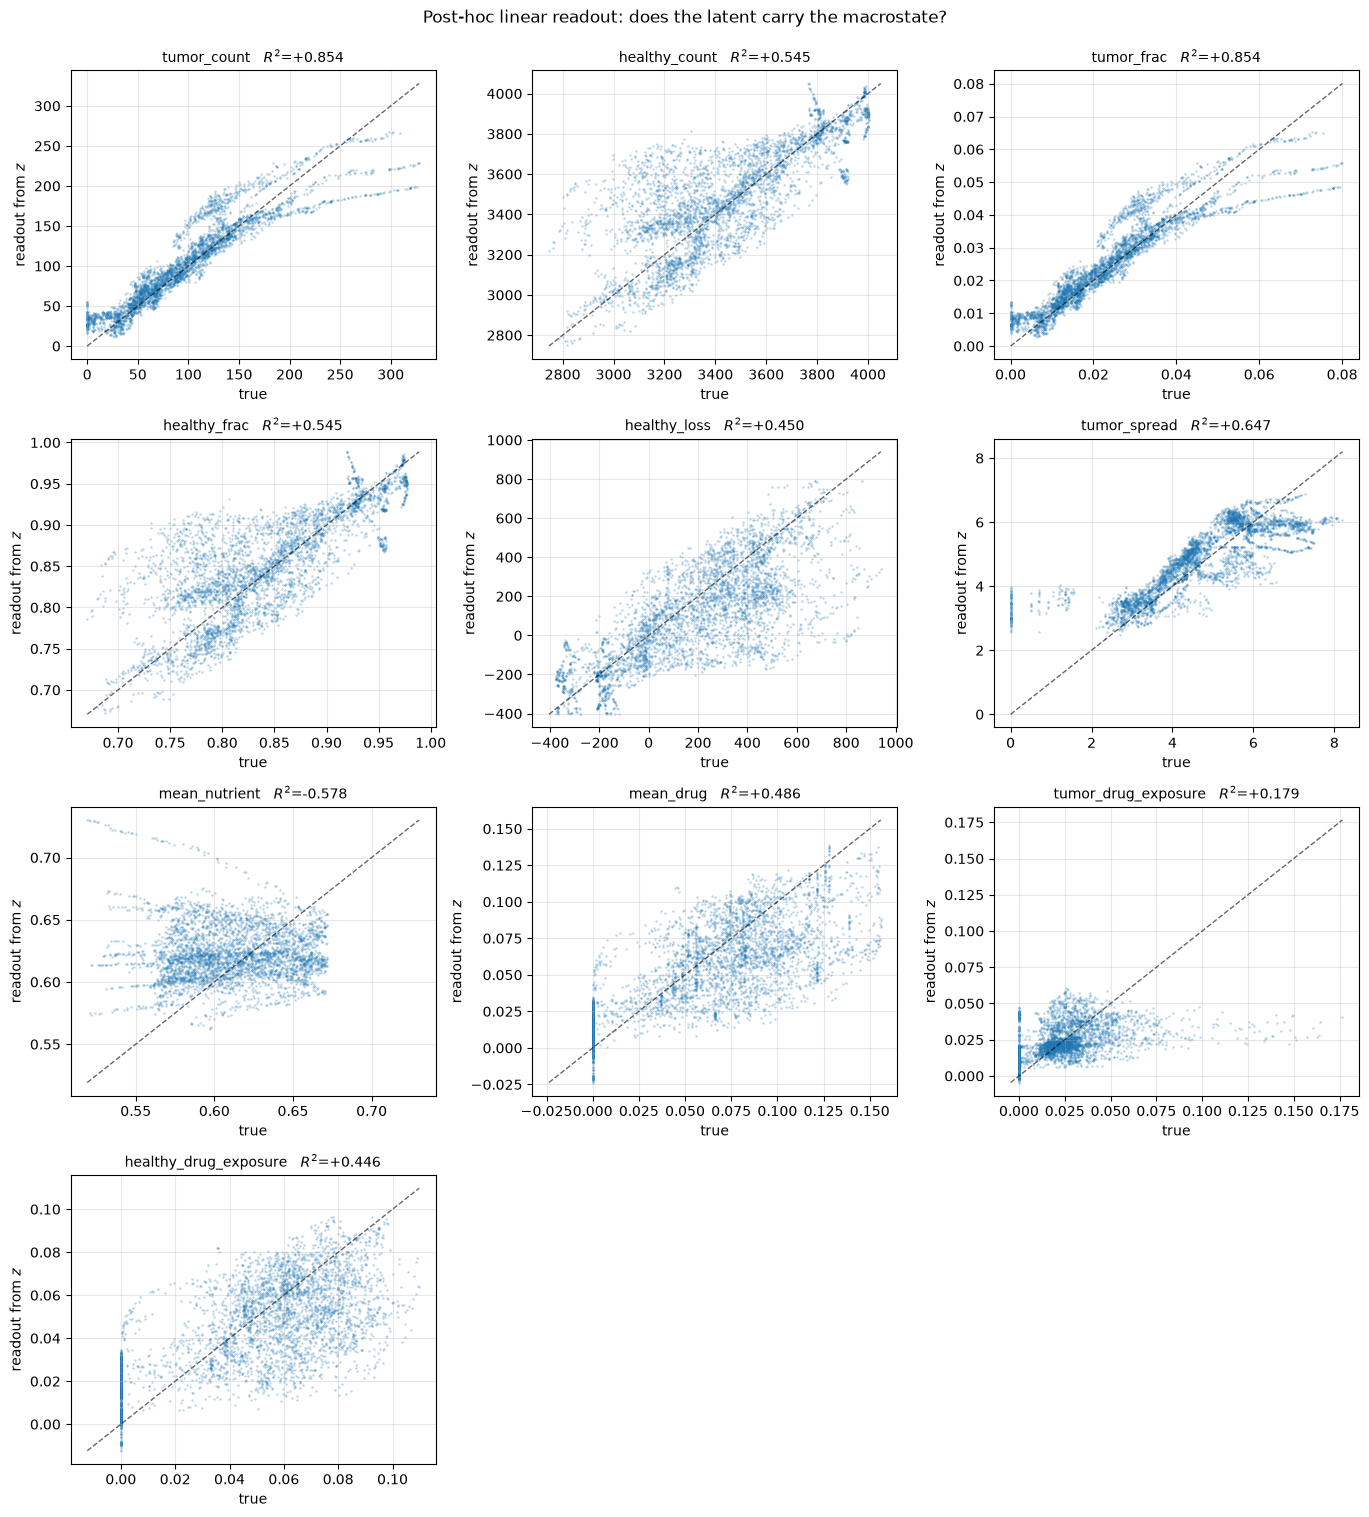

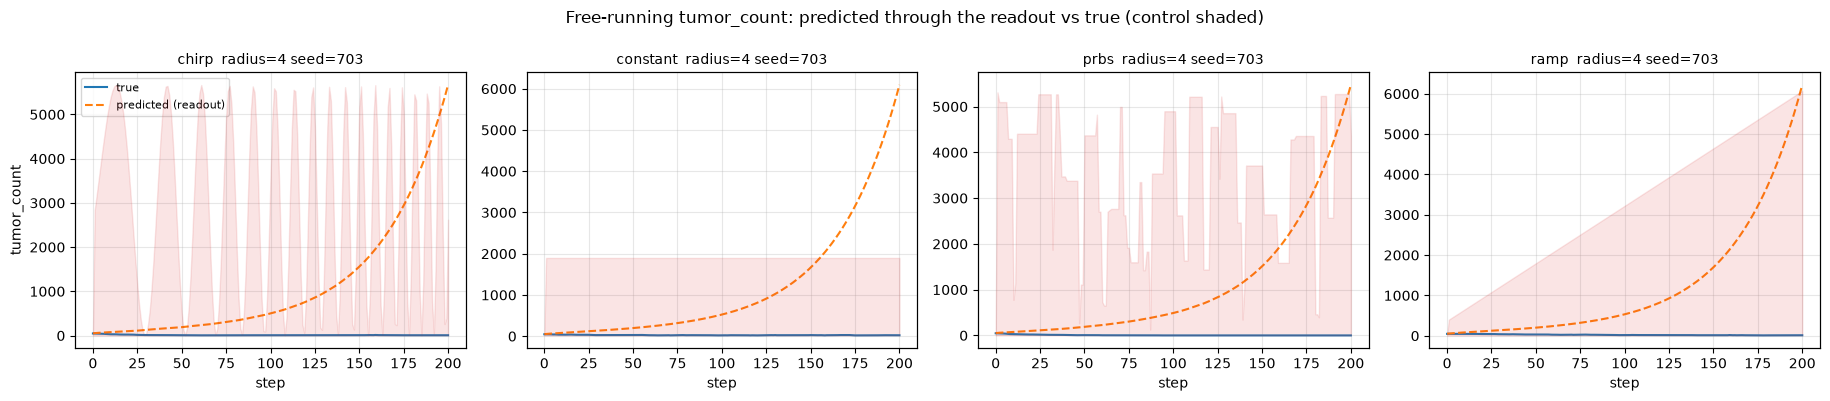

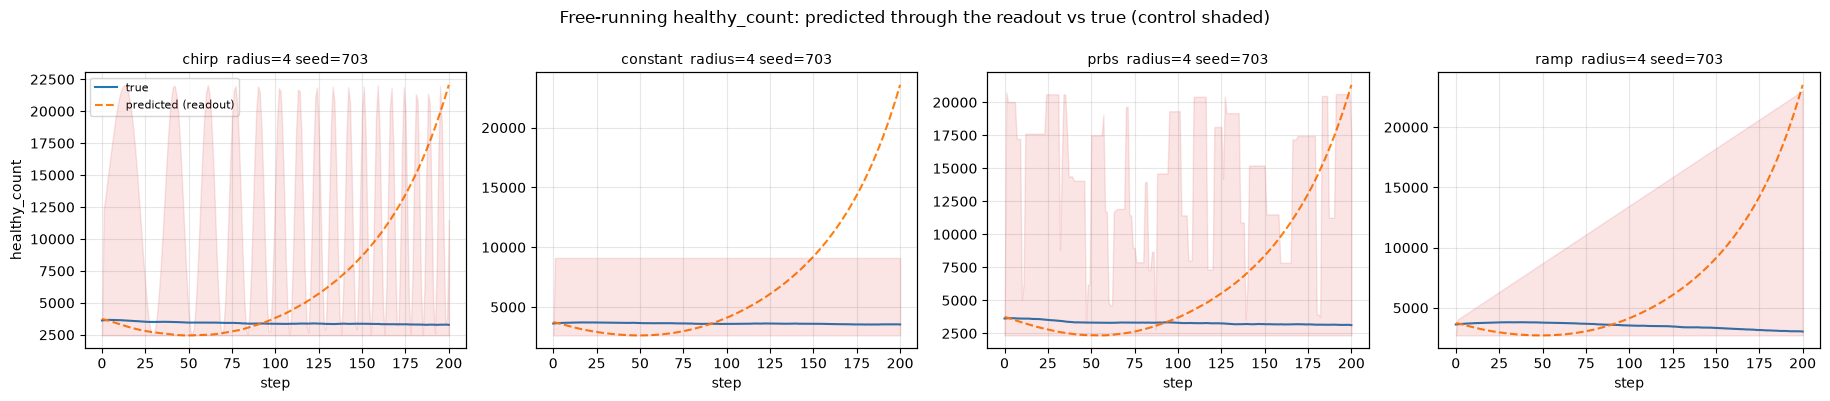

In [8]:
jp.fig_readout_quality(readout, enc, r2_val)
plt.show()

jp.fig_readout_rollout(model, val, readout, n=4, obs_name="tumor_count")
plt.show()

jp.fig_readout_rollout(model, val, readout, n=4, obs_name="healthy_count")
plt.show()

## 8. Does the learned model understand the treatment trade-off?

For each constant dose, this runs matched true-ABM and latent-model trajectories from the same initial conditions. The black curves are the plant; dashed curves are what MPC would believe.

A usable model should predict **lower tumor burden** as dose increases, while also predicting the decline in healthy tissue. Getting only the tumor curve right is insufficient for multi-objective planning.

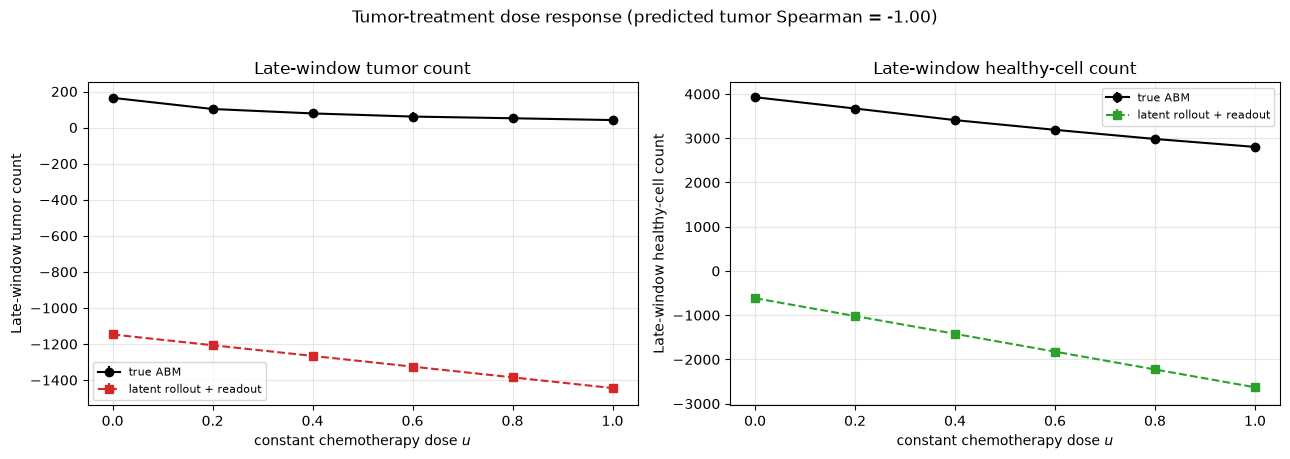

In [9]:
from dataclasses import fields
from koopman_control.data.tumor_tissue import TumorTissueConfig

abm_fields = {f.name for f in fields(TumorTissueConfig)}
abm_kwargs = {k: v for k, v in manifest.get("config", {}).items() if k in abm_fields}
ABM_CFG = TumorTissueConfig(**abm_kwargs)

dose = ev.tumor_dose_response(
    model,
    readout,
    cfg=ABM_CFG,
    u_levels=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
    seeds=(900, 901, 902),
    steps=160,
    initial_healthy_frac=0.94,
    initial_tumor_radius=6.0,
)
jp.fig_tumor_dose_response(dose)
plt.show()

## 9. Multi-objective MPC against the true ABM

At every ABM step, CEM samples candidate chemotherapy sequences inside the learned latent model and minimizes

\[
J = w_T\sum_k\left(\frac{T_k-T^*}{s_T}\right)^2
  + w_H\sum_k\left(\frac{\max(H^*-H_k,0)}{s_H}\right)^2
  + \lambda_u\sum_k u_k^2
  + \lambda_{\Delta u}\sum_k (u_k-u_{k-1})^2.
\]

Only the first dose is applied; the true ABM advances one step and MPC replans. The weights below are scientific assumptions, not learned values. Compare MPC with constant-dose baselines and sweep them before drawing a treatment conclusion.

/var/folders/km/t7rply955cdgx67pfmsv62z80000gn/T/ipykernel_28658/2947083483.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=3)


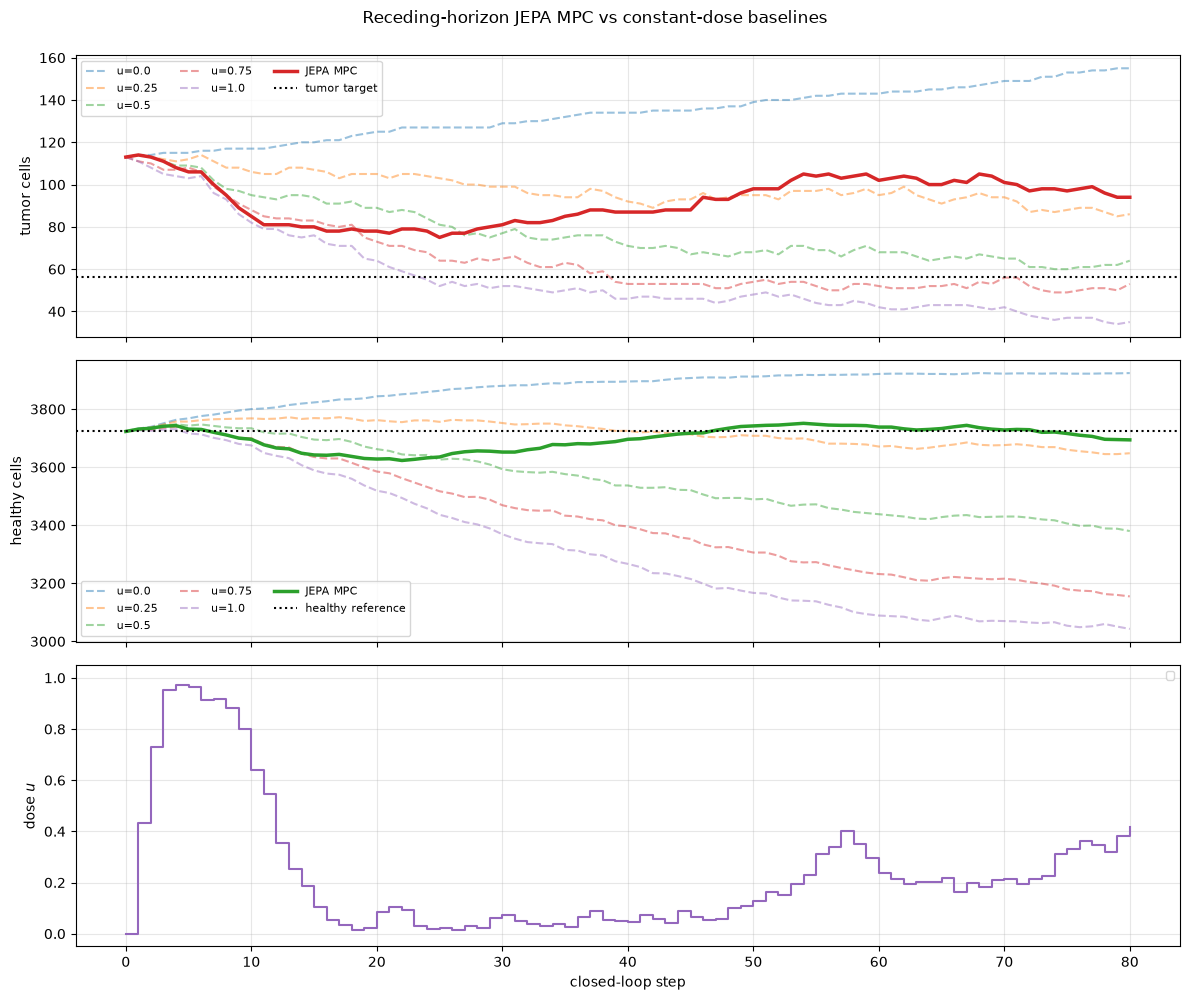

{'final_tumor': 94.0, 'final_healthy': 3694.0, 'mean_dose': 0.2419467717409134, 'cumulative_dose': 19.355741500854492}


In [17]:
from jepa_control.control import TumorMPCConfig, closed_loop_tumor, tumor_baseline_rollouts

MPC_STEPS = 80
BASELINE_LEVELS = (0.0, 0.25, 0.5, 0.75, 1.0)
baselines = tumor_baseline_rollouts(
    steps=MPC_STEPS,
    levels=BASELINE_LEVELS,
    cfg=ABM_CFG,
    initial_healthy_frac=0.94,
    initial_tumor_radius=6.0,
    seed=950,
)
initial_tumor = float(next(iter(baselines.values()))["tumor"][0])
initial_healthy = float(next(iter(baselines.values()))["healthy"][0])
TUMOR_TARGET = 0.5 * initial_tumor

mpc_cfg = TumorMPCConfig(
    # Keep CEM inside the model's trained rollout horizon.
    plan_horizon=SCORE_HORIZON,
    n_samples=128,
    n_iters=3,
    elite_frac=0.1,
    tumor_weight=5.0,
    healthy_weight=0.25,
    control_cost=0.01,
    slew_cost=0.1,
    tumor_scale=max(initial_tumor, 1.0),
    healthy_scale=max(initial_healthy, 1.0),
)
mpc_result = closed_loop_tumor(
    model,
    readout,
    tumor_target=TUMOR_TARGET,
    healthy_reference=initial_healthy,
    steps=MPC_STEPS,
    mpc=mpc_cfg,
    cfg=ABM_CFG,
    initial_healthy_frac=0.94,
    initial_tumor_radius=6.0,
    seed=950,
)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for label, result in baselines.items():
    axes[0].plot(result["tumor"], ls="--", alpha=0.45, label=label)
    axes[1].plot(result["healthy"], ls="--", alpha=0.45, label=label)
axes[0].plot(mpc_result["tumor"], color="C3", lw=2.5, label="JEPA MPC")
axes[0].axhline(TUMOR_TARGET, color="k", ls=":", label="tumor target")
axes[1].plot(mpc_result["healthy"], color="C2", lw=2.5, label="JEPA MPC")
axes[1].axhline(initial_healthy, color="k", ls=":", label="healthy reference")
axes[2].step(np.arange(len(mpc_result["control"])), mpc_result["control"], where="post", color="C4")
axes[0].set_ylabel("tumor cells"); axes[1].set_ylabel("healthy cells"); axes[2].set_ylabel("dose $u$")
axes[2].set_xlabel("closed-loop step"); axes[2].set_ylim(-0.05, 1.05)
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=3)
fig.suptitle("Receding-horizon JEPA MPC vs constant-dose baselines", y=0.995)
fig.tight_layout(); plt.show()

print({k: mpc_result[k] for k in ("final_tumor", "final_healthy", "mean_dose", "cumulative_dose")})

## 10. Final held-out test split

Use validation for iteration and inspect this section only after choices are fixed. Report tumor and healthy performance separately: a model can predict tumor dynamics while missing healthy-tissue toxicity, which would make the resulting controller unsafe even if its tumor objective looks good.

test prediction skill @ h=10: +0.886
test tumor:  readout R²=+0.777, rollout corr=+0.009, RMSE=1758.32
test healthy: readout R²=+0.568, rollout corr=+0.066, RMSE=6186.91
test excitation families: ['chirp', 'constant', 'prbs', 'ramp', 'rpwc', 'staircase', 'zero']


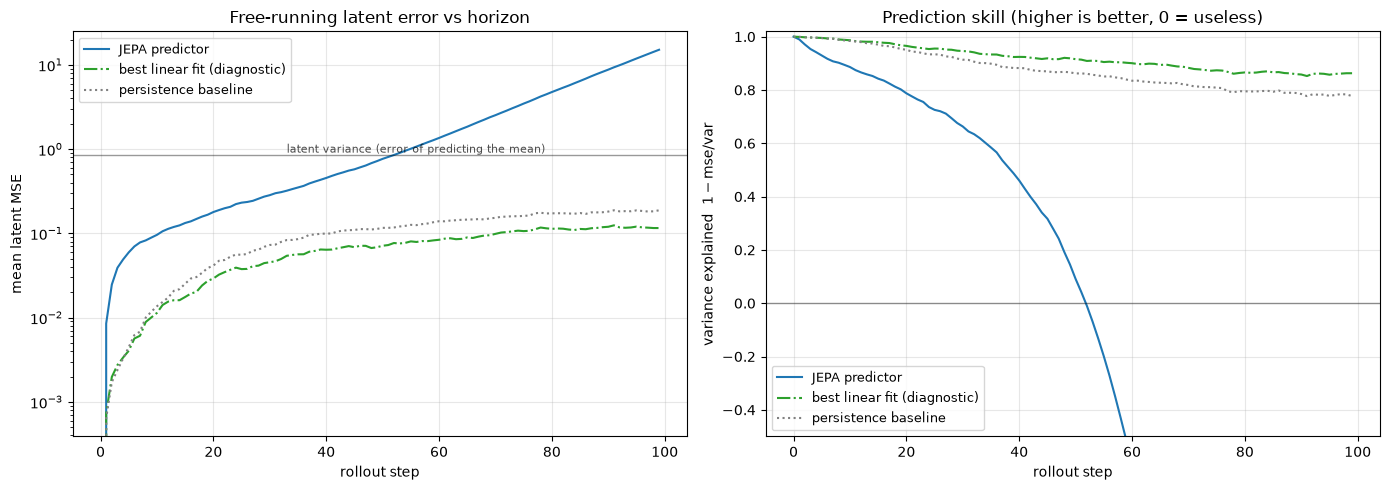

In [11]:
enc_test = ev.encode_all(model, test)
r2_test = ev.readout_r2(readout, enc_test)
herr_test = ev.horizon_errors(model, enc_test, fitted)
tumor_test = ev.readout_rollout_skill(model, enc_test, readout, obs_name="tumor_count")
healthy_test = ev.readout_rollout_skill(model, enc_test, readout, obs_name="healthy_count")
h_test = min(SCORE_HORIZON, len(herr_test["steps"]) - 1)

print(f"test prediction skill @ h={h_test}: {herr_test['skill_full'][h_test]:+.3f}")
print(f"test tumor:  readout R²={r2_test['tumor_count']:+.3f}, rollout corr={tumor_test['corr']:+.3f}, RMSE={tumor_test['rmse']:.2f}")
print(f"test healthy: readout R²={r2_test['healthy_count']:+.3f}, rollout corr={healthy_test['corr']:+.3f}, RMSE={healthy_test['rmse']:.2f}")
print("test excitation families:", sorted({tr["excitation"] for tr in test}))

jp.fig_horizon_errors(herr_test, max_step=min(100, len(herr_test["steps"])))
plt.show()

## 11. Reading the result

A credible result should satisfy all of these:

- **Dataset:** treatment produces graded—not binary—tumor and healthy-cell responses across varied spatial initial conditions.
- **No collapse:** multiple latent dimensions remain active; low prediction loss alone does not establish this.
- **Dynamics:** JEPA beats persistence near the training horizon on validation and test.
- **State legibility:** held-out readout $R^2$ is high for both `tumor_count` and `healthy_count`.
- **Control causality:** predicted dose-response curves have the same direction and approximate scale as the ABM for both populations.
- **Closed loop:** MPC improves the tumor/healthy/dose trade-off over at least one sensible constant-dose baseline, rather than merely choosing a boundary action.
- **ODE baseline:** Section 12. A fitted tumor/healthy/nutrient/drug ODE with oracle macros and the same CEM objective is the strong population-level baseline. Matching or beating it on tumor RMSE *and* healthy-cell shortfall is the bar for claiming the image→latent controller is useful.
- **Robustness:** the conclusion persists across seeds, tumor centers/radii, and reasonable objective-weight sweeps.

Do not interpret one successful closed-loop seed as proof of controller quality. The next rigorous evaluation is a seed-by-initial-condition benchmark that reports tumor burden, healthy-cell shortfall, cumulative dose, and Pareto fronts for MPC and all baselines.

## 12. Baseline: fit a tumor ODE and control with it

Skip images: fit a discrete four-state ODE on `(tumor_count, healthy_count, mean_nutrient, mean_drug)` with delayed chemotherapy delivery, and run the **same multi-objective CEM MPC** with oracle macros each step.

$$
\begin{aligned}
T' &= T + T\,(\alpha_T N - \mu_T - \kappa_T D) \\
H' &= H + H\,(\alpha_H N - \mu_H - \kappa_H D - \pi T) \\
N' &= N + r(1-N) - c_T T - c_H H \\
D' &= D + \delta u + \lambda u_{\mathrm{prev}} - \gamma D
\end{aligned}
$$

Parameters are least-squares fits on one-step deltas from the train probe set. Closed loop still acts on the true tumor ABM, but the ODE planner gets **oracle** population and field means each step (not image → latent → readout). If JEPA cannot match this under the same target / weights / horizon / seed as section 9, the latent controller is not yet earning its complexity.


fitted tumor ODE
  tumor:    growth=-0.0909  death=-0.0576  kill=0.0572
  healthy:  growth=-0.0063  death=-0.0052  kill=0.0225  invasion=0.000005
  nutrient: recover=0.0018  consume_t=0.000001  consume_h=0.000000
  drug:     deliver_now=0.0134  deliver_lag=-0.0032  decay=0.0654
  one-step R²  tumor=+0.014  healthy=+0.175  nutrient=+0.874  drug=+0.674

val free-rollout @ h=10:
  tumor   ODE skill -1.414  (persistence -1.857)
  healthy ODE skill -1.012  (persistence -2.237)

ODE MPC   tumor RMSE 54.1, healthy shortfall 0.0, mean dose 0.142
JEPA MPC  tumor RMSE 55.9, healthy shortfall 0.0, mean dose 0.121
JEPA − ODE tumor RMSE: +1.8  (ODE better)
JEPA − ODE healthy shortfall RMSE: +0.0  (tie)


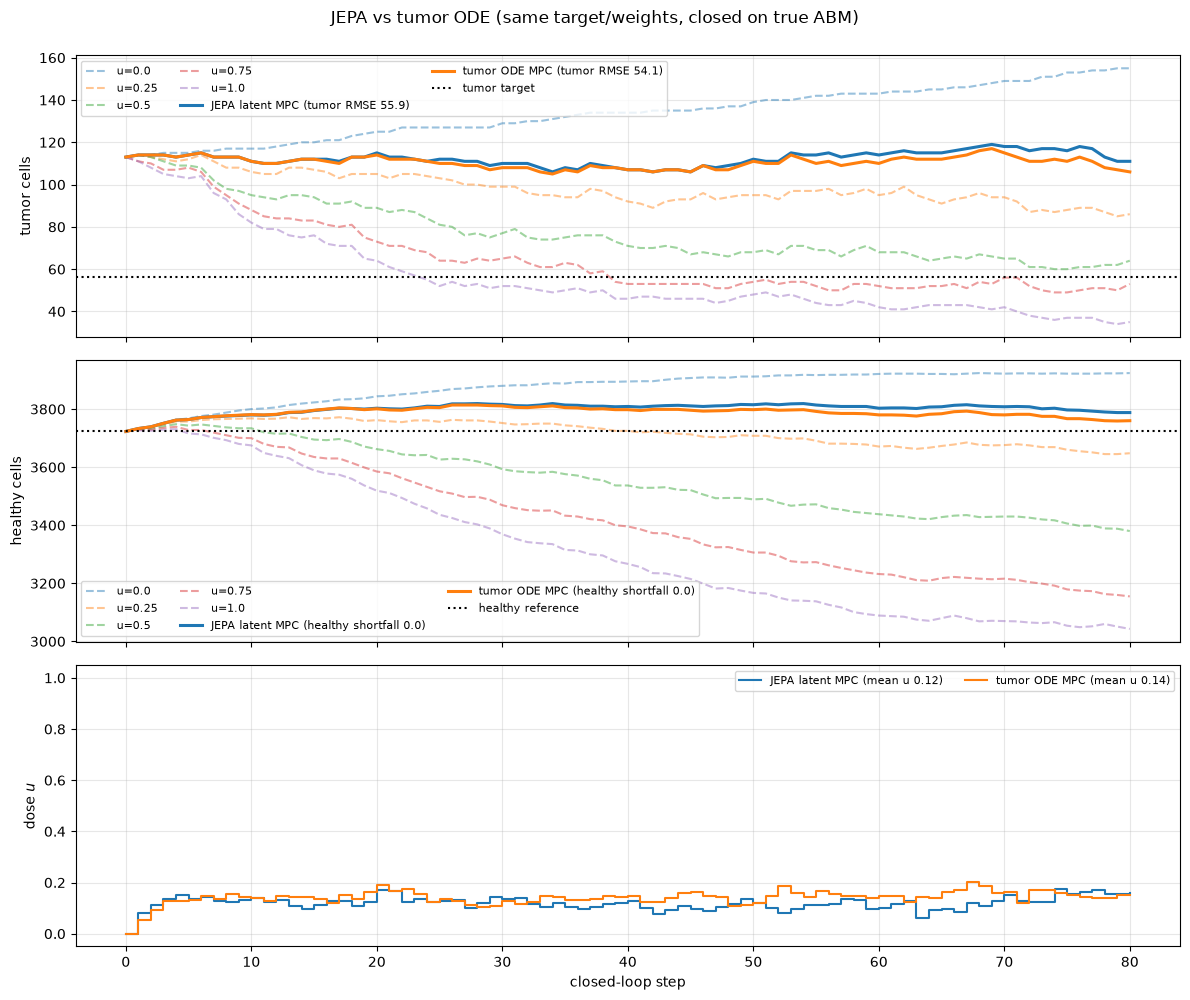

In [ ]:
from jepa_control.ode_baseline import (
    closed_loop_tumor_ode,
    fit_tumor_ode,
    tumor_ode_prediction_skill,
)
from jepa_control.plots import fig_tumor_controller_compare

ode_train = probe_train
ode = fit_tumor_ode(ode_train)
print("fitted tumor ODE")
print(f"  tumor:    growth={ode.growth_t:.4f}  death={ode.death_t:.4f}  kill={ode.kill_t:.4f}")
print(f"  healthy:  growth={ode.growth_h:.4f}  death={ode.death_h:.4f}  "
      f"kill={ode.kill_h:.4f}  invasion={ode.invasion:.6f}")
print(f"  nutrient: recover={ode.recover:.4f}  consume_t={ode.consume_t:.6f}  "
      f"consume_h={ode.consume_h:.6f}")
print(f"  drug:     deliver_now={ode.deliver_now:.4f}  deliver_lag={ode.deliver_lag:.4f}  "
      f"decay={ode.decay:.4f}")
print(f"  one-step R²  tumor={ode.tumor_one_step_r2:+.3f}  "
      f"healthy={ode.healthy_one_step_r2:+.3f}  "
      f"nutrient={ode.nutrient_one_step_r2:+.3f}  "
      f"drug={ode.drug_one_step_r2:+.3f}")

tumor_ode_skill = tumor_ode_prediction_skill(
    val, ode, horizon=SCORE_HORIZON, obs_name="tumor_count"
)
healthy_ode_skill = tumor_ode_prediction_skill(
    val, ode, horizon=SCORE_HORIZON, obs_name="healthy_count"
)
print(f"\nval free-rollout @ h={SCORE_HORIZON}:")
print(f"  tumor   ODE skill {tumor_ode_skill['skill']:+.3f}  "
      f"(persistence {tumor_ode_skill['skill_persistence']:+.3f})")
print(f"  healthy ODE skill {healthy_ode_skill['skill']:+.3f}  "
      f"(persistence {healthy_ode_skill['skill_persistence']:+.3f})")

ode_loop = closed_loop_tumor_ode(
    ode,
    tumor_target=TUMOR_TARGET,
    healthy_reference=initial_healthy,
    steps=MPC_STEPS,
    mpc=mpc_cfg,
    cfg=ABM_CFG,
    initial_healthy_frac=0.94,
    initial_tumor_radius=6.0,
    seed=950,
)
print(f"\nODE MPC   tumor RMSE {ode_loop['tumor_rmse']:.1f}, "
      f"healthy shortfall {ode_loop['healthy_shortfall_rmse']:.1f}, "
      f"mean dose {ode_loop['mean_dose']:.3f}")
print(f"JEPA MPC  tumor RMSE {mpc_result['tumor_rmse']:.1f}, "
      f"healthy shortfall {mpc_result['healthy_shortfall_rmse']:.1f}, "
      f"mean dose {mpc_result['mean_dose']:.3f}")
d_tumor = mpc_result["tumor_rmse"] - ode_loop["tumor_rmse"]
d_healthy = mpc_result["healthy_shortfall_rmse"] - ode_loop["healthy_shortfall_rmse"]
print(
    f"JEPA − ODE tumor RMSE: {d_tumor:+.1f}  "
    f"({'JEPA better' if d_tumor < 0 else 'ODE better' if d_tumor > 0 else 'tie'})"
)
print(
    f"JEPA − ODE healthy shortfall RMSE: {d_healthy:+.1f}  "
    f"({'JEPA better' if d_healthy < 0 else 'ODE better' if d_healthy > 0 else 'tie'})"
)

fig_tumor_controller_compare(
    {"JEPA latent MPC": mpc_result, "tumor ODE MPC": ode_loop},
    baselines,
    title="JEPA vs tumor ODE (same target/weights, closed on true ABM)",
)
plt.show()
